In [1]:
import os

def collect_parent_ids(subset):
    base_dataset = getattr(subset, "dataset", subset)
    indices = getattr(subset, "indices", range(len(subset)))

    parent_ids = set()
    for idx in indices:
        filepath = base_dataset.samples[idx][0]
        filename = os.path.basename(filepath)
        
        # 1. Clean the prefixes
        if filename.startswith("transfer_"):
            filename = filename[len("transfer_"):]
        elif filename.startswith("redigital_"):
            filename = filename[len("redigital_"):]
            
        # 2. Strip the extension (.png or .jpg)
        parent_id, _ = os.path.splitext(filename)
        parent_ids.add(parent_id)
        
    return parent_ids

# Create the loaders if not already in memory
if 'train_loader' not in globals() or 'val_loader' not in globals():
    from src.data.dataloader import get_dataloaders
    train_loader, val_loader = get_dataloaders(data_dir="src/data/RRDataset_final", batch_size=64)

# Get subsets from loaders
train_subset = train_loader.dataset
val_subset = val_loader.dataset

print("Scanning Training Set (Extracting parent IDs)...")
train_parent_ids = collect_parent_ids(train_subset)

print("Scanning Validation Set (Extracting parent IDs)...")
val_parent_ids = collect_parent_ids(val_subset)

# Find the true leakage
leaked_parents = train_parent_ids.intersection(val_parent_ids)

print("\n--- TRUE LEAKAGE REPORT ---")
print(f"Unique parent images in Train: {len(train_parent_ids)}")
print(f"Unique parent images in Val:   {len(val_parent_ids)}")
print(f"TRUE LEAKED PARENT IMAGES:     {len(leaked_parents)}")

if len(leaked_parents) > 0:
    print(f"Percentage of Val subjects leaked: {(len(leaked_parents)/len(val_parent_ids))*100:.2f}%")
    print("\nExamples of leaked parent subjects:")
    for parent in list(leaked_parents)[:5]:
        print(f" - {parent}")
else:
    print("\nZero leakage! Your split is truly safe.")


Loaded 36000 images.
Scanning Training Set (Extracting parent IDs)...
Scanning Validation Set (Extracting parent IDs)...

--- TRUE LEAKAGE REPORT ---
Unique parent images in Train: 13233
Unique parent images in Val:   3309
TRUE LEAKED PARENT IMAGES:     0

Zero leakage! Your split is truly safe.


In [2]:
from src.data.dataloader import get_dataloaders

train_loader, val_loader = get_dataloaders(data_dir="src/data/RRDataset_final", batch_size=64)

# Grab one batch
sample = next(iter(train_loader))

print(f"Images shape: {sample[0].shape}")       # Should be [32, 3, 224, 224]
print(f"Real/Fake labels: {sample[1]}")      # Should be a mix of 0s and 1s
print(f"Transform labels: {sample[2]}")   # Should be a mix of 0s, 1s, and 2s

Loaded 36000 images.
Images shape: torch.Size([64, 3, 224, 224])
Real/Fake labels: tensor([0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1])
Transform labels: tensor([0, 1, 2, 1, 2, 1, 0, 1, 1, 2, 0, 2, 0, 0, 2, 2, 0, 1, 1, 1, 0, 1, 1, 2,
        2, 1, 2, 1, 1, 2, 0, 2, 1, 1, 2, 2, 2, 2, 2, 0, 2, 0, 1, 1, 0, 2, 0, 2,
        0, 2, 0, 0, 1, 0, 1, 2, 0, 0, 2, 0, 1, 1, 1, 2])


In [3]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Import your custom modules directly from the src directory
from src.train.loss import MultiTaskLoss
from src.train.loops import MultiTaskModel, train_epoch
from src.train.ablation import run_ablation_study

# Set device to GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
    )
print(f"Using device: {device}")

Using device: cuda


In [4]:
print("Starting Ablation Study Runs...")
# This will execute the run_ablation_study() function from your module
run_ablation_study(train_loader, val_loader)

Starting Ablation Study Runs...

--- Running iteration with Alpha=0.5, Beta=0.5 ---
Epoch [1/10] - Train Loss: 0.3073, Val Loss: 0.1870
Saving improved model to models/model_05_05.pth...
Epoch [2/10] - Train Loss: 0.1400, Val Loss: 0.1628
Saving improved model to models/model_05_05.pth...
Epoch [3/10] - Train Loss: 0.0963, Val Loss: 0.1678
No improvement. Patience: 1/3
Epoch [4/10] - Train Loss: 0.0778, Val Loss: 0.1533
Saving improved model to models/model_05_05.pth...
Epoch [5/10] - Train Loss: 0.0633, Val Loss: 0.1648
No improvement. Patience: 1/3
Epoch [6/10] - Train Loss: 0.0541, Val Loss: 0.1766
No improvement. Patience: 2/3
Epoch [7/10] - Train Loss: 0.0496, Val Loss: 0.1626
No improvement. Patience: 3/3
Early stopping triggered! Moving to next weight combination.

Ablation Study Complete. Summary:
Weights (alpha=0.5, beta=0.5)
  -> Final Train Loss: 0.0496
  -> Final Val Loss:   0.1626
  -> Final Val Acc (RF): 0.9369
  -> Final Val Acc (TF): 0.9621


Running evaluation on validation set...

--- Final Results ---
Overall Real/Fake Accuracy:   93.49%
Overall Transform Accuracy:   96.38%

--- Advanced Metrics (Real/Fake Task) ---
Precision: 0.9270
Recall:    0.9433
F1 Score:  0.9351
ROC AUC:   0.9350


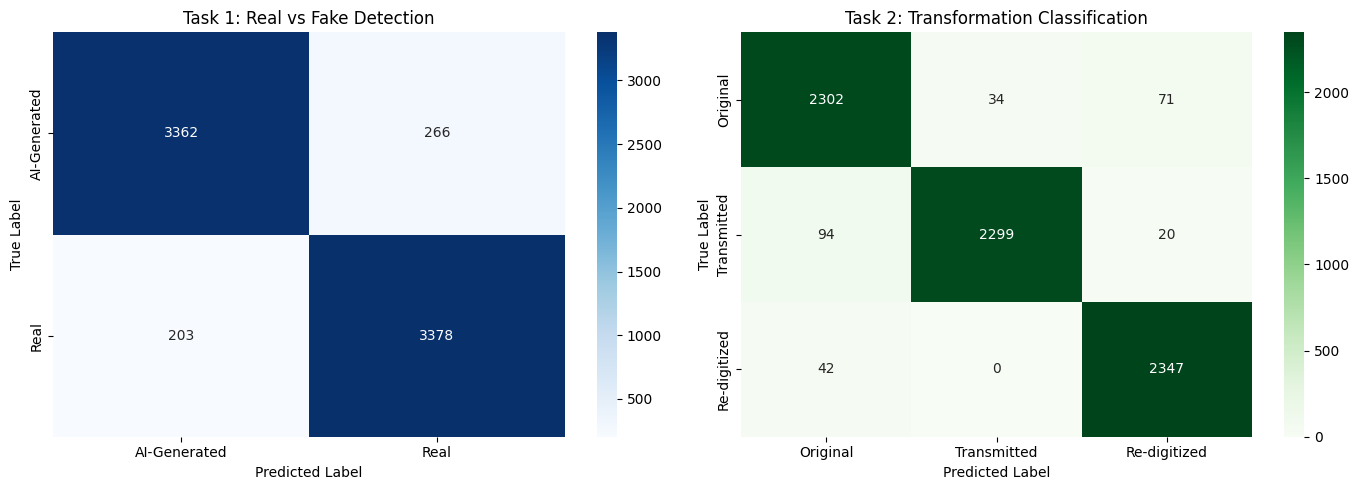

Saved: confusion_matrices.png


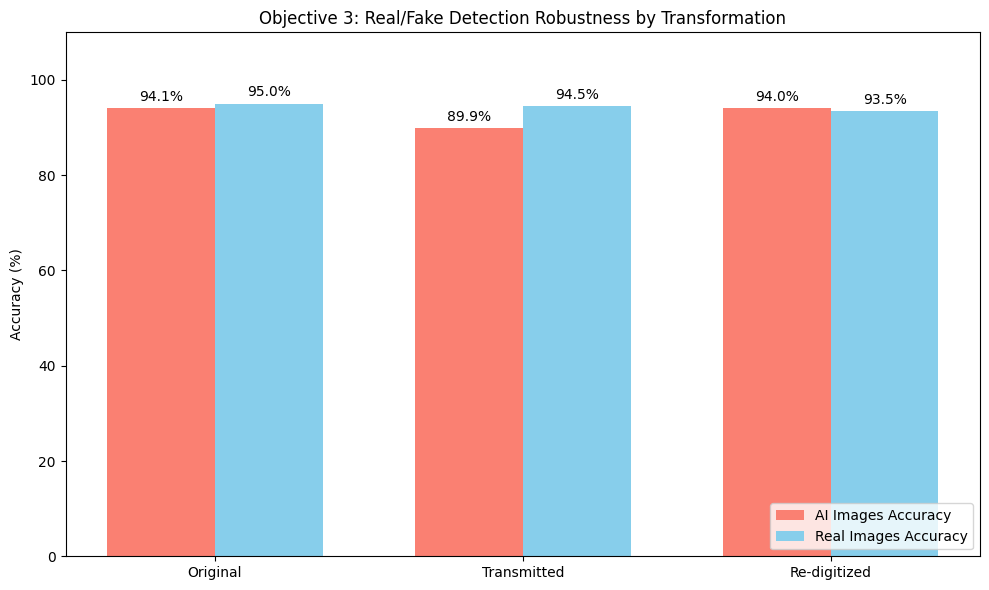

Saved: accuracy_breakdown.png
Grading 0.5_0.5...
Running evaluation on validation set...


In [6]:
import torch
from src.train.loops import MultiTaskModel
from src.evaluation.visualizer import evaluate_model, plot_ablation_study

best_model = MultiTaskModel().to(device)

best_model.load_state_dict(torch.load("models/model_05_05.pth", map_location=device))

evaluate_model(best_model, val_loader, device)

# Plot the ablation study
model_files = {
    #'1.0_0.0': 'models/model_10_00.pth',
    #'0.0_1.0': 'models/model_00_10.pth',
    '0.5_0.5': 'models/model_05_05.pth',
    #'0.8_0.2': 'models/model_08_02.pth',
    #'0.2_0.8': 'models/model_02_08.pth'
}

real_ablation_results = {}

for weight_key, file_path in model_files.items():
    print(f"Grading {weight_key}...")
    
    # Load each saved model one by one
    temp_model = MultiTaskModel().to(device)
    temp_model.load_state_dict(torch.load(file_path, map_location=device))
    
    # Run the validation loop to get the real accuracies
    acc_rf, acc_trans = evaluate_model(temp_model, val_loader, device, quiet_mode=True) 
    
    # Save to your dictionary automatically
    real_ablation_results[weight_key] = (acc_rf * 100, acc_trans * 100)

# 5. Draw the final graph using your real data!
# plot_ablation_study(real_ablation_results)